# Análise Exploratória de Dados — Computer Prices

Notebook de EDA do dataset `computer_prices_train_80.csv` (80.000 linhas x 34 colunas), preparando o terreno para a etapa de tratamento.

| Etapa | Descricao |
|-------|----------|
| (1.0) | Imports e configuracoes |
| (2.0) | Visao geral do dataset |
| (3.0) | Analise do target (`price`) |
| (4.0) | Analise de outliers |
| (5.0) | Correlacao e multicolinearidade |
| (6.0) | Analise bivariada |

**Objetivo:** entender a distribuicao dos precos, identificar outliers e relações entre features, fundamentando as decisoes de engenharia de features e higienizacao do `Tratamento.ipynb`.

# (1.0) Imports e Configurações

Bibliotecas gerais e funcoes auxiliares do modulo `utils`.

In [1]:
# Importando bibliotecas dessa análise
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from typing import Union
import math
from scipy.stats import trim_mean
from utils import (
    analisar_valores_nulos,
    resumo_estatistico,
    histograma_simples,
    plot_distribuicao,
    plot_boxplot_outliers,
    plot_correlacao_alvo,
    plot_dispersao_tendencia,
    plot_categoria_preco,
    analisar_multicolinearidade_pares,
    plotar_boxplot_faixa
)

%load_ext autoreload
%autoreload 2

# Configuração de estilo para os gráficos 
sns.set_theme(style="whitegrid")

# Ignorar avisos 
import warnings
warnings.filterwarnings('ignore')

caminho = os.path.join(os.getcwd(), 'Arquivos', 'computer_prices_train_80.csv')

## (2.0) Visão Geral do Dataset

Carregamento, inspecao da estrutura (tipos e contagens), verificacao de valores nulos e inventario das variaveis categoricas.

In [2]:
df = pd.read_csv(caminho)


display(df.head(10))



,ID,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,...,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,3813,Laptop,Acer,Acer Creator HGG,2020,macOS,Ultrabook,Intel,Intel i5-12462,2,...,1920x1080,120,80,65,0,Wi-Fi 7,5.2,1.57,12,1046.99
1,99183,Desktop,ASUS,ASUS Creator 4FF,2020,Windows,ATX,Intel,Intel i5-12752,2,...,2560x1440,60,0,0,450,Wi-Fi 6,5.1,10.00,48,894.99
2,80737,Laptop,Apple,Apple Pro XOU,2024,macOS,Ultrabook,Apple,Apple M3 Pro,4,...,2560x1600,165,60,45,0,Wi-Fi 5,5.2,2.37,24,2281.99
3,65674,Laptop,Apple,Apple Think RUD,2025,Windows,Workstation,Apple,Apple M3 Pro,4,...,1920x1080,60,56,120,0,Wi-Fi 6,5.2,1.12,24,2608.99
4,53670,Desktop,Dell,Dell Arena MK6,2022,Windows,Micro-ATX,AMD,AMD Ryzen 7 3564,5,...,1920x1080,90,0,0,1200,Wi-Fi 6,5.0,9.00,24,1933.99
5,97104,Desktop,Apple,Apple Cube JBQ,2021,macOS,ATX,Apple,Apple M3 Pro,4,...,2560x1440,60,0,0,750,Wi-Fi 7,5.1,7.00,36,2568.99
6,38743,Laptop,ASUS,ASUS Zen 7C1,2018,Windows,Ultrabook,AMD,AMD Ryzen 5 7714,3,...,3840x2160,60,50,65,0,Wi-Fi 5,5.0,1.57,36,2138.99
7,36888,Desktop,Dell,Dell Forge MCU,2020,Windows,ATX,Intel,Intel i5-10987,2,...,1920x1080,60,0,0,550,Wi-Fi 5,5.0,6.00,24,1222.99
8,75154,Desktop,Lenovo,Lenovo Creator 9R8,2021,Windows,Mini-ITX,Intel,Intel i5-13726,2,...,3840x2160,60,0,0,550,Wi-Fi 6,5.0,12.00,24,1424.99
9,1326,Laptop,Apple,Apple Nitro G3M,2023,Linux,Mainstream,Apple,Apple M1 Pro,2,...,1920x1080,144,70,120,0,Wi-Fi 6,5.0,1.57,12,1580.99


In [3]:
display(df.info())


# 33 features e 1 target

# 80.000 linhas


<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   80000 non-null  int64  
 1   device_type          80000 non-null  str    
 2   brand                80000 non-null  str    
 3   model                80000 non-null  str    
 4   release_year         80000 non-null  int64  
 5   os                   80000 non-null  str    
 6   form_factor          80000 non-null  str    
 7   cpu_brand            80000 non-null  str    
 8   cpu_model            80000 non-null  str    
 9   cpu_tier             80000 non-null  int64  
 10  cpu_cores            80000 non-null  int64  
 11  cpu_threads          80000 non-null  int64  
 12  cpu_base_ghz         80000 non-null  float64
 13  cpu_boost_ghz        80000 non-null  float64
 14  gpu_brand            80000 non-null  str    
 15  gpu_model            80000 non-null  str    
 1

None

> ### Insights Iniciais:
> 
> 33 colunas e 1 target
>
> **80k colunas** --> Muitos dados

### (2.1) Valores Nulos

Verificacao rapida de missing values em todo o dataset.

In [4]:
analisar_valores_nulos(df)

Nenhum valor nulo encontrado no DataFrame!


,Total Nulos,Percentual (%),Tipo de Dado


> 
> Sem valores nulos do dataset, aparentemente ele já foi "pré-tratado" anteriormente ou foi obtido por meio de uma boa engenharia de dados
> 

### (2.2) Tipagem das Variáveis

Contagem de colunas numéricas vs. categoricas.

In [5]:
num_cols = df.select_dtypes(include=["number"]).shape[1]

cat_cols = df.select_dtypes(include=["object", "category"]).shape[1]

display(f"Numero de colunas numericas: {num_cols}")
display(f"Numero de colunas categoricas: {cat_cols}")

'Numero de colunas numericas: 21'

'Numero de colunas categoricas: 13'

> ### Sobre as Features/Variáveis
> 
> **21 numéricas** (Incluindo o Target) (62%)
>
> **13 categoricas** (38%)
> 

### (2.3) Inventário das Variáveis Categóricas

Subconjunto de colunas `object`/`category` para inspecao visual e resumo de cardinalidade.

In [6]:
df_categorico = df.select_dtypes(include=["object", "category"])

display(df_categorico)


,device_type,brand,model,os,form_factor,cpu_brand,cpu_model,gpu_brand,gpu_model,storage_type,display_type,resolution,wifi
0,Laptop,Acer,Acer Creator HGG,macOS,Ultrabook,Intel,Intel i5-12462,AMD,RX 6000 50,NVMe,VA,1920x1080,Wi-Fi 7
1,Desktop,ASUS,ASUS Creator 4FF,Windows,ATX,Intel,Intel i5-12752,NVIDIA,RTX 40 50,NVMe,LED,2560x1440,Wi-Fi 6
2,Laptop,Apple,Apple Pro XOU,macOS,Ultrabook,Apple,Apple M3 Pro,Apple,Apple Integrated,NVMe,Mini-LED,2560x1600,Wi-Fi 5
3,Laptop,Apple,Apple Think RUD,Windows,Workstation,Apple,Apple M3 Pro,Apple,Apple Integrated,SSD,QLED,1920x1080,Wi-Fi 6
4,Desktop,Dell,Dell Arena MK6,Windows,Micro-ATX,AMD,AMD Ryzen 7 3564,Intel,Arc A700,NVMe,Mini-LED,1920x1080,Wi-Fi 6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,Laptop,HP,HP Pro JIY,Linux,Ultrabook,AMD,AMD Ryzen 7 3134,NVIDIA,RTX 40 80,Hybrid,IPS,1920x1080,Wi-Fi 5
79996,Laptop,Gigabyte,Gigabyte Pro SVH,Windows,Workstation,AMD,AMD Ryzen 7 6499,NVIDIA,RTX 40 60,NVMe,OLED,1920x1080,Wi-Fi 6
79997,Desktop,Apple,Apple Pro KF4,macOS,ATX,Apple,Apple M1 Pro,Apple,Apple Integrated,Hybrid,OLED,2560x1440,Wi-Fi 6
79998,Laptop,ASUS,ASUS Blade DIK,Windows,Gaming,Intel,Intel i7-10529,AMD,RX 6000 90,NVMe,LED,1920x1080,Wi-Fi 5


> ### Sobre as Features Categóricas
> 
> **Model / CPU model** Nome dos modelos dos computadores/cpu não parece ser algo a interessar numa análise (Remover)
>
> **Brand** é uma métrica importante, mais abaixo você verá que marcas como Apple possuem maior valor agregado de seus produtos
> 
> **Resolution** que é atualmente categórica poderia ser transformada numa coluna de Área de Resolução, numérica.
>
> **Wifi** pode sofrer um label enconding, dá pra atribuir ordinalidade nos wifis. Os mais modernos tendem a ser melhores
>
> **Storage_Type** tambem pode sofrer um label enconding interessante

In [7]:
resumo_cat = pd.DataFrame([
    {
        'Coluna': col,
        'Valores Únicos': df_categorico[col].nunique(),
        'Nulos': df_categorico[col].isnull().sum(),
        'Valores / Amostra': (
            list(df_categorico[col].unique()) 
            if df_categorico[col].nunique() <= 8 
            else list(df_categorico[col].unique()[:5]) + ['...']
        )
    }
    for col in df_categorico.columns
])

display(resumo_cat)

,Coluna,Valores Únicos,Nulos,Valores / Amostra
0,device_type,2,0,"[Laptop, Desktop]"
1,brand,10,0,"[Acer, ASUS, Apple, Dell, Lenovo, ...]"
2,model,79352,0,"[Acer Creator HGG, ASUS Creator 4FF, Apple Pro..."
3,os,4,0,"[macOS, Windows, Linux, ChromeOS]"
4,form_factor,10,0,"[Ultrabook, ATX, Workstation, Micro-ATX, Mini-..."
5,cpu_brand,3,0,"[Intel, Apple, AMD]"
6,cpu_model,25308,0,"[Intel i5-12462, Intel i5-12752, Apple M3 Pro,..."
7,gpu_brand,4,0,"[AMD, NVIDIA, Apple, Intel]"
8,gpu_model,49,0,"[RX 6000 50, RTX 40 50, Apple Integrated, Arc ..."
9,storage_type,4,0,"[NVMe, SSD, Hybrid, HDD]"



> 
> **Model / CPU model / GPU_model** realmente devem ser removidos para evitar uma alta dimensionalidade ao sofrer possíveis one-hot encondings

# (3.0) Análise do Target (`price`)

Estatisticas descritivas, histograma e comparacao de transformacoes (original, `log1p`, `log`) para decidir qual representacao usar como alvo nos modelos.

### (3.1) Estatísticas Descritivas do Preço

Media, mediana, desvio padrao, quartis, IQR, assimetria e curtose do preco original.

In [8]:
resumo_estatistico(df, coluna='price')

,Métrica,Valor
0,Média,"$1,929.63"
1,Mediana,"$1,863.99"
2,Desvio Padrão,$579.59
3,Mínimo,$372.99
4,1º Quartil (Q1 - 25%),"$1,504.99"
5,3º Quartil (Q3 - 75%),"$2,287.99"
6,Intervalo Interquartil (IQR),$783.00
7,Máximo,"$9,772.99"
8,Assimetria (Skewness),0.96
9,Curtose (Kurtosis),4.32


> ### Métricas estatísticas
> 
> **Média/Mediana** valores próximos de 1900, indicando a priori uma interessante faixa de valores. Ademais por terem um gap de menos de 100$ ( relativamente 6%) não indica grande presença de outliers
>
> **Mínimo** 372$ é um valor bem baixo, o modelo pode ser impactado por essa observação
> 
> **Máximo** 9773$ valor muito alto, será que é um supercomputador ou um erro?
>
> **Desvio Padrao** na faixa de 600$, realmente existe uma diversidade de preços para os computadores.
>
> **Assimetria** 0,96 positiva, indica cauda a direita considerável. Deve haver consideráveis outliers a direita
>
> **Curtose** 4,32 indica que o pico é bem acentuado na faixa dos 1900$

### (3.2) Histograma do Preço

Distribuicao de frequencia do preco bruto em 30 bins.

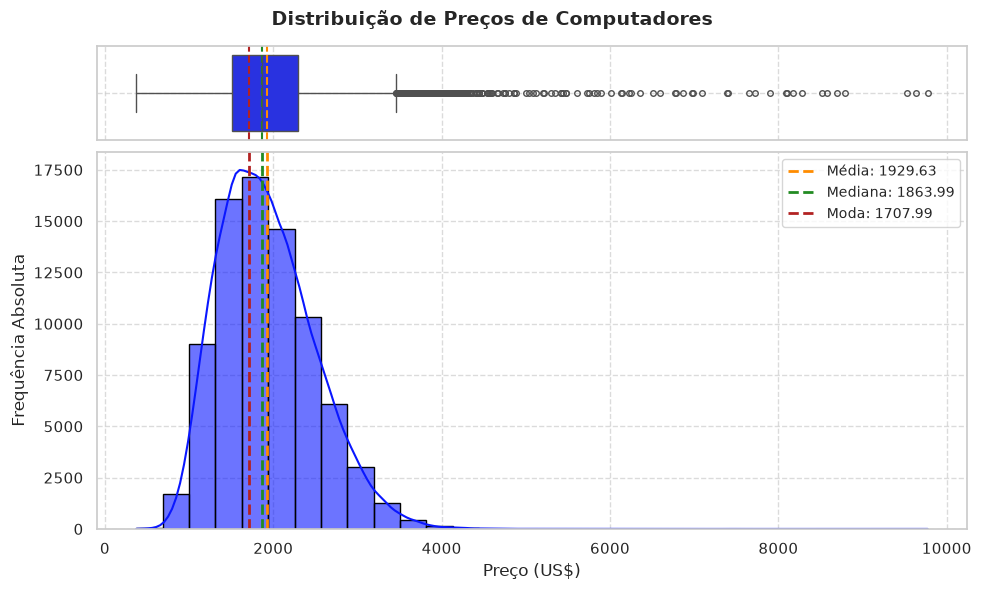

In [9]:
histograma_simples(
    df=df,
    coluna='price', 
    bins=30, 
    titulo='Distribuição de Preços de Computadores', 
    xlabel='Preço (US$)', 
    ylabel='Frequência Absoluta', 
    color="#0A17FF"
)

### (3.3) Comparação de Transformações

Compara a distribuicao original com transformacoes logaritmicas (`log1p`, `log`) para escolher a representacao mais simetrica do target.

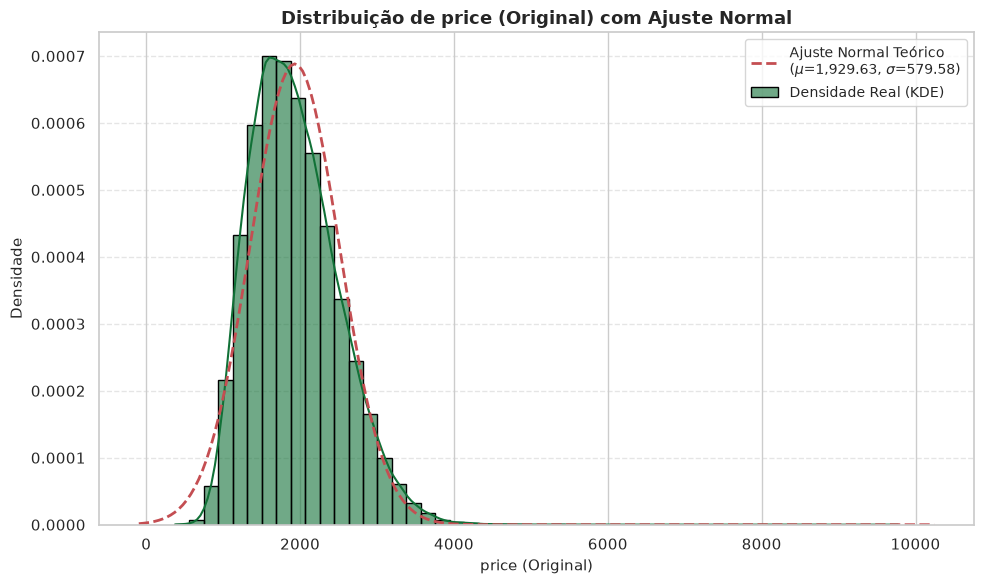

,Transformação,Média,Mediana,Desvio Padrão,Assimetria (Skew),Curtose (Kurt)
0,Original,1929.6324,1863.9900,579.5874,0.9584,4.3242


In [10]:
plot_distribuicao(df, coluna='price', transformacao='original', cor="#117137")

> Curtose 4.32 e Assimetria 0.95

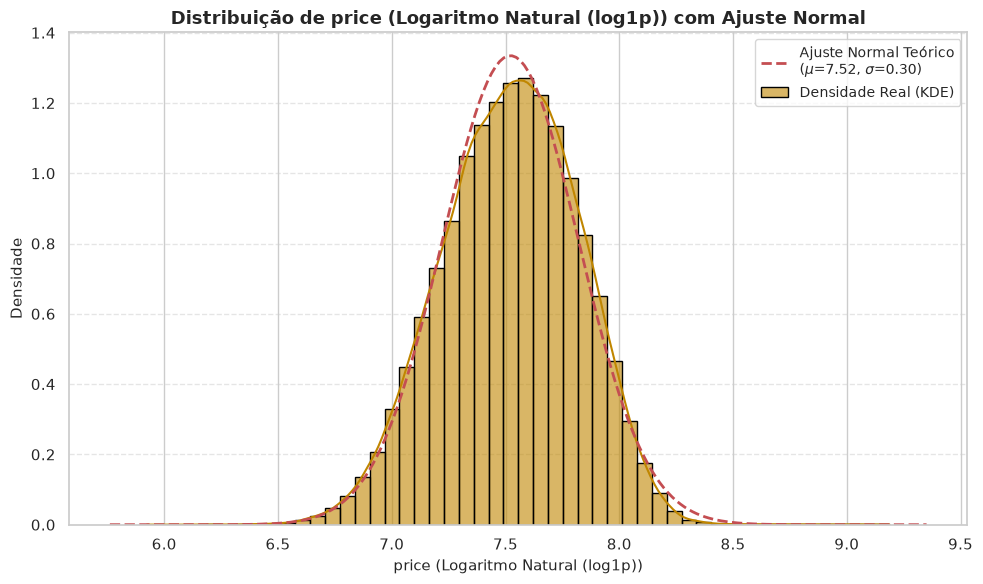

,Transformação,Média,Mediana,Desvio Padrão,Assimetria (Skew),Curtose (Kurt)
0,Logaritmo Natural (log1p),7.5215,7.5310,0.2989,-0.1320,-0.0421


In [11]:
plot_distribuicao(df, coluna='price', transformacao='log1p', cor = "#C08600")


> Curtose (-0.04) e Assimetria (0.13)
>
> **Excelentes valores, muito próximos da normal para ln(1+x)**
>

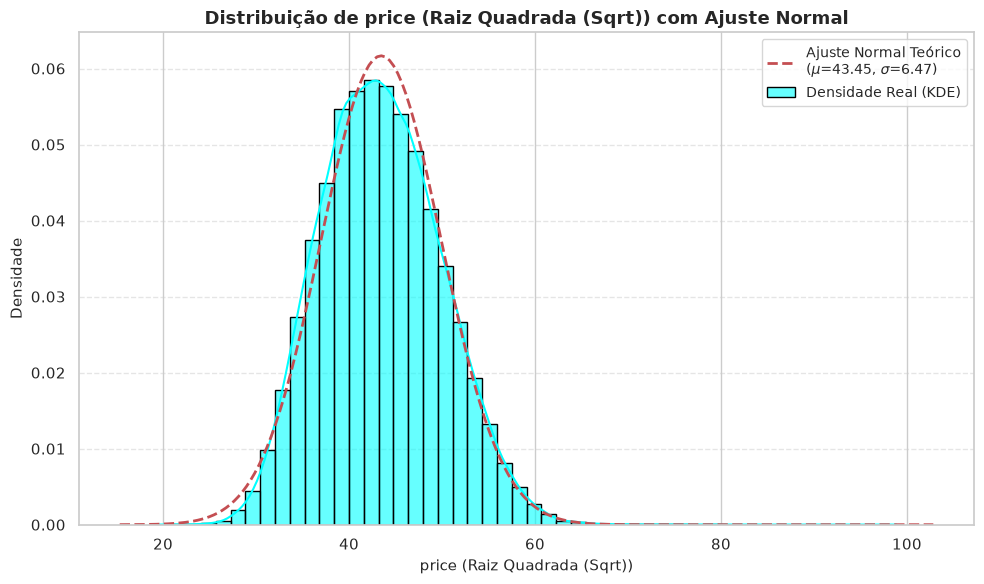

,Transformação,Média,Mediana,Desvio Padrão,Assimetria (Skew),Curtose (Kurt)
0,Raiz Quadrada (Sqrt),43.4487,43.1740,6.4685,0.3283,0.5841


In [12]:
plot_distribuicao(df, coluna='price', transformacao='sqrt', cor = "#00FFFF")

> Assimetria 0.3283 e Curtose 0.5481

# (4.0) Análise de Outliers

Investiga as caudas da distribuicao de precos usando IQR sobre `price_log` (mais robusto que sobre o preco bruto), identificando limites superiores e inferiores para a etapa de higienizacao.

### (4.1) Resumo Estatístico do `price_log`

Cria a coluna `price_log = ln(1 + price)` e recalcula as estatisticas descritivas.

In [13]:
df['price_log'] = np.log1p(df['price'])


resumo_estatistico(df, coluna='price_log')

,Métrica,Valor
0,Média,$7.52
1,Mediana,$7.53
2,Desvio Padrão,$0.30
3,Mínimo,$5.92
4,1º Quartil (Q1 - 25%),$7.32
5,3º Quartil (Q3 - 75%),$7.74
6,Intervalo Interquartil (IQR),$0.42
7,Máximo,$9.19
8,Assimetria (Skewness),-0.13
9,Curtose (Kurtosis),-0.04


> ### Métricas estatísticas do log1p
> 
> **Métricas com bem menos influência de desvio padrão, mais próximas da curva normal**

### (4.2) Média Aparada (Trimmed Mean)

Media aparada em 10% de cada lado — medida robusta para comparar com a media aritmetica e avaliar a influencia de valores extremos.

In [14]:
media_aparada= trim_mean(df['price_log'], 0.1) #5% superior e 5% inferior
media_comum = df['price_log'].mean
display(f"media aparada = {media_aparada} ")


'media aparada = 7.5263064137217865 '

> A princípio não parece haver muitos outliers, a média aparada está consistente com a média comum

### (4.3) Boxplot e IQR

Limites de outlier via IQR (1,5 x IQR) em `price` e `price_log`, com contagem de registros acima/abaixo dos limites.

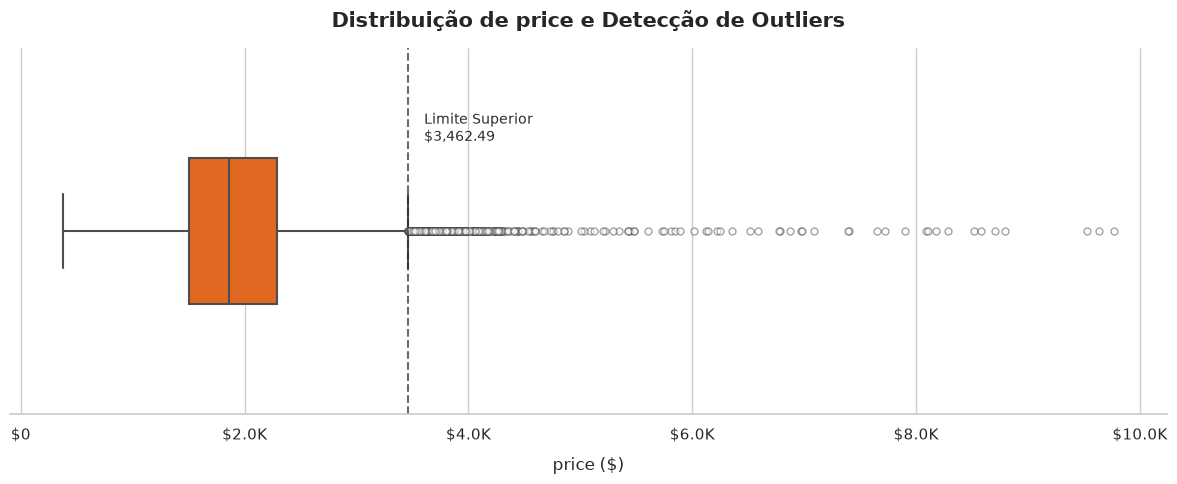

--- Diagnóstico de Outliers: price ---
Limite Superior (Q3 + 1.5*IQR): 3,462.49
Limite Inferior (Q1 - 1.5*IQR): 330.49
Outliers Superiores: 782 registros
Outliers Inferiores: 0 registros
Total de Outliers: 782 (0.98%)


{'limite_inferior': np.float64(330.49000000000046),
 'limite_superior': np.float64(3462.4899999999993),
 'qtd_outliers_sup': 782,
 'qtd_outliers_inf': 0,
 'total_outliers': 782}

In [15]:
plot_boxplot_outliers(df,coluna = 'price', cor="#FF6200", monetario = True)


> Menos de 1% de outliers a direita relevantes

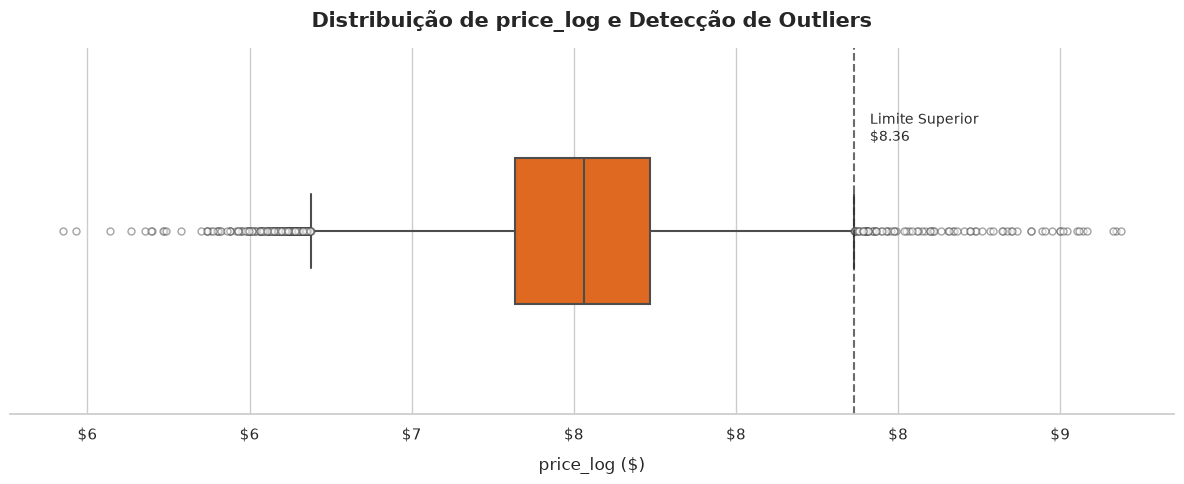

--- Diagnóstico de Outliers: price_log ---
Limite Superior (Q3 + 1.5*IQR): 8.36
Limite Inferior (Q1 - 1.5*IQR): 6.69
Outliers Superiores: 82 registros
Outliers Inferiores: 230 registros
Total de Outliers: 312 (0.39%)


{'limite_inferior': np.float64(6.689215493744291),
 'limite_superior': np.float64(8.36385622571032),
 'qtd_outliers_sup': 82,
 'qtd_outliers_inf': 230,
 'total_outliers': 312}

In [16]:
df_novo = np.log1p(df['price'])

plot_boxplot_outliers(df,coluna = 'price_log', cor="#FF6200", monetario = True)

> A transformação log1p deixou **outliers a direita e a esquerda**, mesmo assim, há menos em número do que para o `price` comum.

> Há **82 superiores e 230 inferiores**

### (4.4) Investigação dos Outliers

Conversao dos limites de volta para a escala original (`expm1`) e listagem das linhas identificadas como outliers superiores e inferiores.

In [17]:
outlier_alto= math.expm1(8.36)

print(outlier_alto)

df_outliers_superiores = df[ (df['price'] >= outlier_alto) ]

display(df_outliers_superiores)

4271.694766395488


,ID,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,...,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price,price_log
207,64831,Desktop,HP,HP Think 1FC,2022,Windows,Micro-ATX,AMD,AMD Ryzen 7 7131,5,...,60,0,0,450,Wi-Fi 5,5.3,8.00,12,9633.99,9.173157
2547,5705,Laptop,Apple,Apple Air 3AW,2025,macOS,Mainstream,Apple,Apple M1 Max,4,...,120,56,90,0,Wi-Fi 6E,5.0,1.50,24,4483.99,8.408492
4270,52804,Laptop,Apple,Apple Think WJ4,2025,macOS,2-in-1,Apple,Apple M3 Pro,6,...,165,90,90,0,Wi-Fi 5,5.0,1.13,24,4277.99,8.361472
4407,64192,Laptop,Lenovo,Lenovo Think Z3H,2025,Windows,Gaming,Intel,Intel i5-10208,2,...,120,70,90,0,Wi-Fi 5,5.2,1.50,36,4443.99,8.399533
4454,36091,Laptop,Apple,Apple Blade NW3,2021,Windows,Ultrabook,Apple,Apple M2 Pro,5,...,120,90,90,0,Wi-Fi 6,5.2,1.10,36,9529.99,9.162304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76255,65097,Laptop,Lenovo,Lenovo Think SVE,2023,Windows,Ultrabook,Intel,Intel i7-12983,5,...,60,70,120,0,Wi-Fi 7,5.0,1.37,12,8173.99,9.008835
76268,44855,Desktop,Lenovo,Lenovo Think CHH,2022,Windows,SFF,AMD,AMD Ryzen 7 6395,5,...,60,0,0,1000,Wi-Fi 6E,4.2,7.00,36,6138.99,8.722578
77274,47543,Desktop,HP,HP Think 9CJ,2020,Windows,Micro-ATX,Intel,Intel i5-13584,2,...,60,0,0,850,Wi-Fi 6E,5.1,16.00,24,4672.99,8.449768
78295,18117,Laptop,Apple,Apple Think 05F,2024,Windows,Workstation,Apple,Apple M1 Max,6,...,60,90,120,0,Wi-Fi 6,5.2,1.57,12,4409.99,8.391854


> ### Outliers superiores
> 
> **Presença de supercomputadores** Os dois mais caros computadores, por exemplo, pesam 7kg em média e possuem quantidades anormais de ram_gb (64 e 96)
>
> **Presença de supercomputadores de elite** Mesmas métricas bizarras de supercomputadores, mas em formato laptop ( peso é condizente com laptop)
>
> **Não parece viável manter esses outliers pro treino dos modelos**

In [18]:
outlier_baixo = math.expm1(6.69)

print(outlier_baixo)

df_outliers_inferiores = df[ (df['price'] <= outlier_baixo) ]

display(df_outliers_inferiores)

803.322252143982


,ID,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,...,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price,price_log
144,71099,Desktop,Lenovo,Lenovo Strix QQM,2024,Windows,Micro-ATX,AMD,AMD Ryzen 5 7617,2,...,120,0,0,550,Wi-Fi 6,5.1,12.00,24,776.99,6.656714
1126,64863,Laptop,Acer,Acer Legion C59,2019,Windows,2-in-1,Intel,Intel i3-14350,1,...,90,60,65,0,Wi-Fi 5,5.0,1.50,24,715.99,6.575062
1507,57993,Desktop,Acer,Acer Think X5Y,2025,Linux,ATX,Intel,Intel i3-11758,1,...,144,0,0,650,Wi-Fi 7,5.2,6.00,12,724.99,6.587536
1775,84706,Desktop,ASUS,ASUS Station WVZ,2021,ChromeOS,SFF,Intel,Intel i7-12880,5,...,60,0,0,650,Wi-Fi 6,5.1,4.00,24,588.99,6.380106
1820,26120,Desktop,ASUS,ASUS Creator 57I,2020,Windows,ATX,Intel,Intel i3-12841,1,...,60,0,0,1200,Wi-Fi 5,5.2,13.00,24,683.99,6.529404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78152,68412,Laptop,HP,HP Zen UPW,2018,Windows,2-in-1,Intel,Intel i5-11306,2,...,60,60,120,0,Wi-Fi 6E,5.0,0.92,36,684.99,6.530863
78697,84107,Desktop,Dell,Dell Strix POQ,2021,Windows,Micro-ATX,AMD,AMD Ryzen 3 6860,1,...,60,0,0,450,Wi-Fi 5,5.0,6.00,24,799.99,6.685848
78714,53993,Desktop,Acer,Acer Think KX7,2022,Windows,Full-Tower,AMD,AMD Ryzen 3 6220,1,...,60,0,0,650,Wi-Fi 6E,5.1,4.00,12,764.99,6.641169
79606,44235,Desktop,Dell,Dell Arena 53K,2019,ChromeOS,ATX,Intel,Intel i3-13309,1,...,120,0,0,850,Wi-Fi 6,5.1,11.00,48,640.99,6.464573


> ### Outliers inferiores
> 
> **Métricas de Ram/GPU Tier fazem muita diferença** O computador mais barato (370$), por exemplo, tem resolução de 3840 x 2160, 120Hz, é caracterizado como gaming mas como seu gpu tier = 1 e ram_gb = 8 ele foi bem rebaixado
>
> 
> **Presença de possíveis promoções** Há computadores que possuem boas características mas estão com seu valor bem mais barato. Não parece ser um erro na base, mas realmente possíveis queima de estoques
>
> **Não parece viável manter esses outliers pro treino dos modelos**

# (5.0) Correlação e Multicolinearidade

Correlacao de Pearson das features numéricas com o alvo (`price_log`) e identificacao de pares de features altamente correlacionadas entre si (> 0,80).

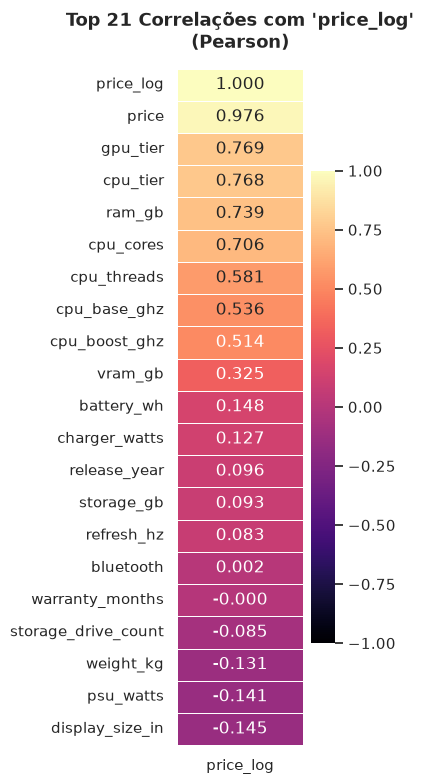

,price_log
price_log,1.000000
price,0.976405
gpu_tier,0.768610
cpu_tier,0.767946
ram_gb,0.739125
cpu_cores,0.705787
cpu_threads,0.581319
cpu_base_ghz,0.536237
cpu_boost_ghz,0.514156
vram_gb,0.325090


In [19]:
from utils import plot_correlacao_alvo

df_todas_correlacoes = plot_correlacao_alvo(
    df=df, 
    alvo='price_log', 
    top_n=21, 
    metodo='pearson', 
    cor='magma',
)


display(df_todas_correlacoes)

> ### Features com mais correlação:
> 
> **Métricas de GPU/CPU/Ram  carregam o preço do computador** A princípio essas features do processamento são essenciais para o preço do computador. As 10 primeiras features são todas relacionadas a aspectos de processamento
>
> 
> **Mais compacto = Melhor** Pra notebooks, ser compacto e potente é um fator que eleva seu preço. Inclusive, o peso do pc impacta negativamente no preço
>

In [20]:
analisar_multicolinearidade_pares(df, limite=0.80)

--- Pares com Correlação > 0.8 ---
price & price_log: 0.976
cpu_base_ghz & cpu_boost_ghz: 0.961
cpu_tier & cpu_cores: 0.937
gpu_tier & ram_gb: 0.913
cpu_cores & ram_gb: 0.907
cpu_tier & ram_gb: 0.899
cpu_cores & cpu_threads: 0.899
display_size_in & battery_wh: 0.897
battery_wh & psu_watts: 0.896
display_size_in & psu_watts: 0.881
cpu_tier & gpu_tier: 0.857
cpu_tier & cpu_threads: 0.849
psu_watts & weight_kg: 0.826
battery_wh & weight_kg: 0.819
cpu_threads & ram_gb: 0.814
cpu_tier & cpu_base_ghz: 0.813
cpu_cores & gpu_tier: 0.812
display_size_in & weight_kg: 0.810


> ### Multicolinearidade
> 
> **Métricas semelhantes carregam multicolinearidade** Para um modelo linear ou mais simples é o caso carregar uma métrica de CPU, uma métrica de GPU, uma de ram etc. Pois as submétricas de CPU/GPU / etc tem multicolinearidade alta entre elas.
>
> 
> **Métricas de tamanho/peso são multicolineares** métricas de peso/tamanho de tela/ bateria parecem ter uma colinearidade, talvez seja válida trabalhá-las como uma única feature
>

# (6.0) Análise Bivariada

Graficos de dispersao e comparacao de precos medios por categoria para identificar relações diretas entre features e o target.

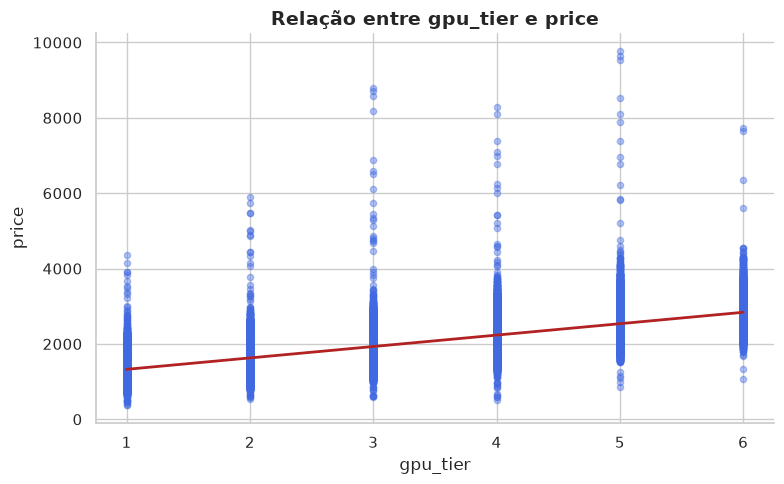

In [ ]:
plot_dispersao_tendencia(df, x_col='gpu_tier', y_col='price')

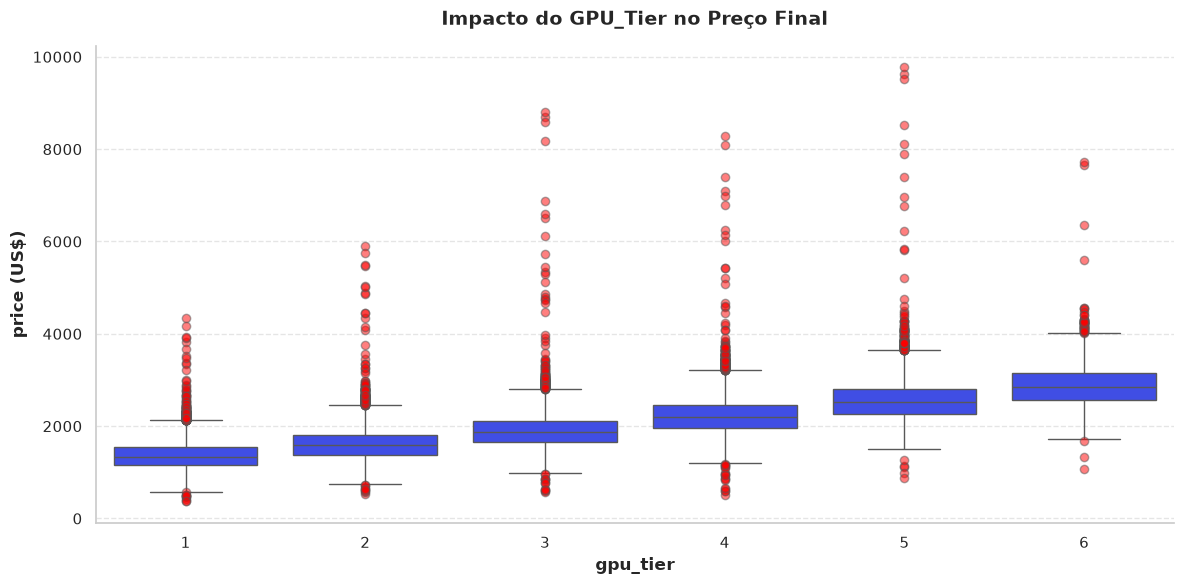

In [27]:
plotar_boxplot_faixa(df, col_x='gpu_tier', col_y='price',titulo='Impacto do GPU_Tier no Preço Final',cor="#2537FF")

> ### Impacto do gpu_tier
> 
> A métrica mais forte gpu_tier embora seja a mais importante, ainda produz outliers, pois as outras métricas impactam no preço 
>

### (6.1) Preço Médio por Marca

Ranking das marcas por preco medio — destaca o premio da Apple sobre as demais.

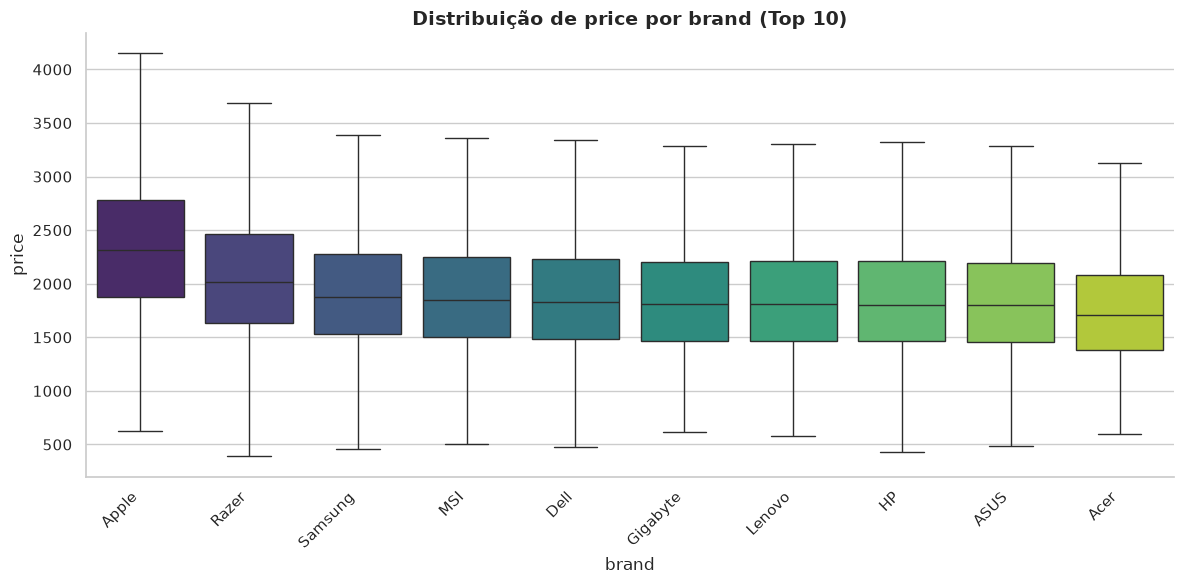

In [23]:
plot_categoria_preco(df, col_cat='brand', col_alvo='price', top_n=10)

> ### Impacto do Brand
> 
> Apple visivelmente possui preços bem mais elevados em relação as outras marcas
>

In [24]:
df.groupby('brand')['price'].mean().sort_values(ascending=False)

brand
Apple       2358.636657
Razer       2078.062240
Samsung     1933.957026
MSI         1905.979492
Dell        1884.186145
Lenovo      1864.623230
Gigabyte    1864.373393
HP          1862.398265
ASUS        1851.844102
Acer        1760.823564
Name: price, dtype: float64

In [29]:
df['price'].quantile(0.75)

np.float64(2287.99)